In [23]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

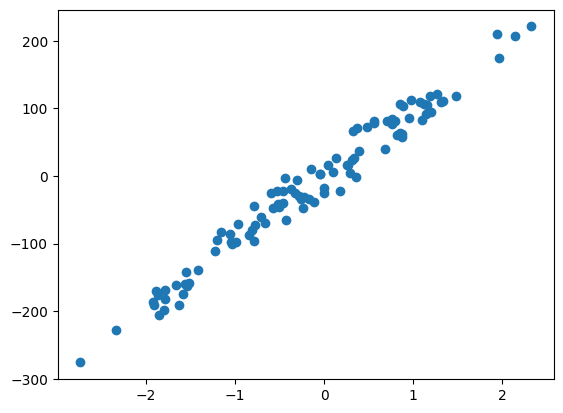

In [6]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)
plt.scatter(X,y)
plt.show()

#### Using Sci_Kit Learn

In [7]:
from sklearn.linear_model import LinearRegression

In [29]:
lr = LinearRegression()
lr.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
print(lr.coef_,lr.intercept_)

[96.04617111] -0.7833554243356922


In [24]:
np.mean(cross_val_score(lr,X,y,scoring='r2',cv=10))

np.float64(0.9415978703749109)

In [34]:
class GDRegressor :
    def __init__(self,learning_rate,epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self,X,y) :
        # Calculate b using Gradient Descent
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m * X.ravel() - self.b)
            self.b = self.b - (self.lr * loss_slope_b)
            loss_slope_m = -2 * np.sum((y - self.m * X.ravel() - self.b) * X.ravel())
            self.m = self.m - (self.lr * loss_slope_m)
        print(self.b,self.m)

    def predict(self,X):
        return self.m * X + self.b

In [26]:
# Before adding m calculator in our class

gd = GDRegressor(0.1,10)

In [20]:
gd.fit(X,y)

-730928855369324.9


Learning Rate is too high that's why we get such value for b

In [21]:
gd = GDRegressor(0.01,10)
gd.fit(X,y)

-120.0


In [36]:
# After adding m calculator in our class

gd = GDRegressor(0.001,100)
gd.fit(X,y)

-0.7833555366074626 96.04617106243104


Nearly same values

In [37]:
gd.predict(X[0])

array([24.68517096])

In [40]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [41]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
y_pred = lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9675510366797777

In [44]:
gd.fit(X_train,y_train)
y_pred_gd = gd.predict(X_test)
r2_score(y_test,y_pred_gd)

0.297889507594497 95.40060783403892


0.9675510367134088

Nearly same results